# 05 - wpływ szumu w strukturze grafu
Analiza odporności grafowych sieci neuronowych na usuwanie krawędzi.
Symuluje scenariusz gdzie struktura grafu jest niekompletna lub zaszumiona.

In [1]:
import os, json
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv, GATConv, SAGEConv

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

dataset = Planetoid(root='../data/Cora', name='Cora')
data = dataset[0]
original_train_mask = data.train_mask.clone()
original_edge_index = data.edge_index.clone()

print(f'Węzły:     {data.num_nodes}')
print(f'Krawędzie: {data.num_edges}')
print(f'Klasy:     {dataset.num_classes}')

Węzły:     2708
Krawędzie: 10556
Klasy:     7


In [2]:
with open('../models/all_results.json') as f:
    all_raw = json.load(f)

# wyniki przy 5% etykiet - punkt odniesienia (0% szumu)
baseline_accs = {
    name: np.mean(res['0.05'])
    for name, res in all_raw.items()
    if name != 'MLP'
}

print('Baseline accuracy (5% etykiet, 0% szumu):')
for name, acc in baseline_accs.items():
    print(f'  {name:<12}: {acc:.4f}')

Baseline accuracy (5% etykiet, 0% szumu):
  GCN         : 0.7922
  GAT         : 0.8058
  GraphSAGE   : 0.7952


## Architektury modeli

In [3]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=0.6)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=0.6)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

MODELS = {
    'GCN':       (GCN,       {'in_channels': dataset.num_features, 'hidden_channels': 64,  'out_channels': dataset.num_classes}),
    'GAT':       (GAT,       {'in_channels': dataset.num_features, 'hidden_channels': 8,   'out_channels': dataset.num_classes}),
    'GraphSAGE': (GraphSAGE, {'in_channels': dataset.num_features, 'hidden_channels': 64,  'out_channels': dataset.num_classes}),
}
OPTIMIZERS = {
    'GCN':       {'lr': 0.01},
    'GAT':       {'lr': 0.005, 'weight_decay': 5e-4},
    'GraphSAGE': {'lr': 0.01,  'weight_decay': 5e-4},
}

## Funkcje pomocnicze

In [4]:
def create_split(data, label_ratio, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    available_indices = (~data.test_mask).nonzero(as_tuple=True)[0]
    train_size = int(data.num_nodes * label_ratio)
    shuffled = available_indices[torch.randperm(len(available_indices))]
    train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    train_mask[shuffled[:train_size]] = True
    return train_mask

def drop_edges(edge_index, drop_ratio, seed=42):
    """Losowo usuwa drop_ratio% krawędzi z grafu.
    Symuluje niekompletne lub zaszumione dane o cytowaniach.
    """
    torch.manual_seed(seed)
    num_edges = edge_index.size(1)
    mask = torch.rand(num_edges) > drop_ratio
    return edge_index[:, mask]

def train(model, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test(model):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
    return acc.item()

# test funkcji
for ratio in [0.0, 0.1, 0.3, 0.5]:
    noisy = drop_edges(original_edge_index, ratio)
    remaining = noisy.size(1) / original_edge_index.size(1) * 100
    print(f'Drop {ratio:.0%}: zostaje {noisy.size(1)} krawędzi ({remaining:.1f}%)')

Drop 0%: zostaje 10556 krawędzi (100.0%)
Drop 10%: zostaje 9502 krawędzi (90.0%)
Drop 30%: zostaje 7382 krawędzi (69.9%)
Drop 50%: zostaje 5267 krawędzi (49.9%)


## Eksperymenty - accuracy vs % usuniętych krawędzi
Stały split: 5% etykiet (najtrudniejszy scenariusz)
Każdy poziom szumu powtórzony 3 razy z różnymi seedami.

In [5]:
drop_ratios = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]
noise_seeds = [42, 123, 456]
label_ratio = 0.05  # stałe 5% etykiet

noise_results = {name: defaultdict(list) for name in MODELS}

for model_name, (ModelClass, model_kwargs) in MODELS.items():
    print(f'\n=== {model_name} ===')
    for drop_ratio in drop_ratios:
        for noise_seed in noise_seeds:
            # split treningowy
            data.train_mask = create_split(data, label_ratio, seed=42)
            # szum na krawędziach
            data.edge_index = drop_edges(original_edge_index, drop_ratio, seed=noise_seed)

            model = ModelClass(**model_kwargs)
            optimizer = torch.optim.Adam(model.parameters(), **OPTIMIZERS[model_name])

            for epoch in range(200):
                train(model, optimizer)

            acc = test(model)
            noise_results[model_name][drop_ratio].append(acc)
            print(f'  Drop {drop_ratio:.0%}, Seed {noise_seed}: {acc:.4f}')

# oryginalne krawędzie i maskę
data.edge_index = original_edge_index
data.train_mask = original_train_mask

print('\n--- Podsumowanie ---')
drop_labels = [f'{int(r*100)}%' for r in drop_ratios]
print(f'{"Model":<12}', '  '.join(f'{l:>8}' for l in drop_labels))
print('-' * 70)
for name in MODELS:
    row = f'{name:<12}'
    for dr in drop_ratios:
        accs = noise_results[name][dr]
        row += f'  {np.mean(accs):.4f}'
    print(row)


=== GCN ===
  Drop 0%, Seed 42: 0.7930
  Drop 0%, Seed 123: 0.7910
  Drop 0%, Seed 456: 0.7990
  Drop 10%, Seed 42: 0.7880
  Drop 10%, Seed 123: 0.7850
  Drop 10%, Seed 456: 0.7930
  Drop 20%, Seed 42: 0.7810
  Drop 20%, Seed 123: 0.7730
  Drop 20%, Seed 456: 0.7880
  Drop 30%, Seed 42: 0.7630
  Drop 30%, Seed 123: 0.7580
  Drop 30%, Seed 456: 0.7710
  Drop 50%, Seed 42: 0.7180
  Drop 50%, Seed 123: 0.7470
  Drop 50%, Seed 456: 0.7510
  Drop 70%, Seed 42: 0.6390
  Drop 70%, Seed 123: 0.6770
  Drop 70%, Seed 456: 0.6670

=== GAT ===
  Drop 0%, Seed 42: 0.7950
  Drop 0%, Seed 123: 0.8060
  Drop 0%, Seed 456: 0.7860
  Drop 10%, Seed 42: 0.7950
  Drop 10%, Seed 123: 0.7990
  Drop 10%, Seed 456: 0.8020
  Drop 20%, Seed 42: 0.7730
  Drop 20%, Seed 123: 0.7700
  Drop 20%, Seed 456: 0.7950
  Drop 30%, Seed 42: 0.7690
  Drop 30%, Seed 123: 0.7450
  Drop 30%, Seed 456: 0.7720
  Drop 50%, Seed 42: 0.7180
  Drop 50%, Seed 123: 0.7580
  Drop 50%, Seed 456: 0.7530
  Drop 70%, Seed 42: 0.6650
  Drop

## Spadek accuracy względem baseline (0% szumu)

In [6]:
print('--- Spadek accuracy względem 0% szumu ---')
print(f'{"Model":<12}', '  '.join(f'{l:>8}' for l in drop_labels[1:]))
print('-' * 65)
for name in MODELS:
    base = np.mean(noise_results[name][0.0])
    row = f'{name:<12}'
    for dr in drop_ratios[1:]:
        drop = np.mean(noise_results[name][dr]) - base
        row += f'  {drop:+.4f}'
    print(row)

--- Spadek accuracy względem 0% szumu ---
Model             10%       20%       30%       50%       70%
-----------------------------------------------------------------
GCN           -0.0057  -0.0137  -0.0303  -0.0557  -0.1333
GAT           +0.0030  -0.0163  -0.0337  -0.0527  -0.1113
GraphSAGE     -0.0070  -0.0177  -0.0510  -0.0903  -0.1457


## Wizualizacja

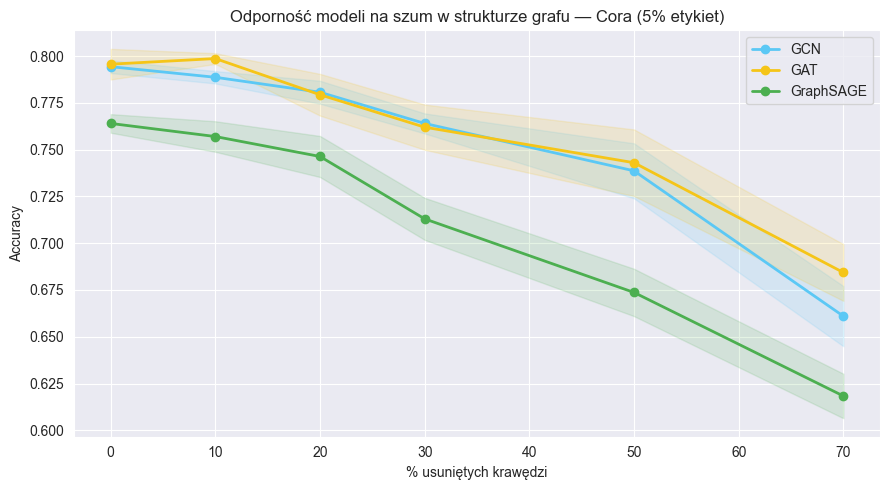

Wykres zapisany: ../results/edge_noise.png


In [7]:
drop_pct = [r * 100 for r in drop_ratios]

plt.figure(figsize=(9, 5))
for name in MODELS:
    means = [np.mean(noise_results[name][dr]) for dr in drop_ratios]
    stds  = [np.std(noise_results[name][dr])  for dr in drop_ratios]
    plt.plot(drop_pct, means,
             marker='o',
             linewidth=2, label=name)
    plt.fill_between(drop_pct,
                     [m - s for m, s in zip(means, stds)],
                     [m + s for m, s in zip(means, stds)],
                     alpha=0.15)

plt.xlabel('% usuniętych krawędzi')
plt.ylabel('Accuracy')
plt.title('Odporność modeli na szum w strukturze grafu - Cora (5% etykiet)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/edge_noise.png')
plt.show()
print('Wykres zapisany: ../results/edge_noise.png')

In [8]:
noise_serializable = {
    name: {str(k): v for k, v in res.items()}
    for name, res in noise_results.items()
}
with open('../models/noise_results.json', 'w') as f:
    json.dump(noise_serializable, f, indent=2)

print('Zapisano:')
print('../models/noise_results.json')
print('../results/edge_noise.png')

Zapisano:
../models/noise_results.json
../results/edge_noise.png
